# Input-Output Space Mapping with Flow Matching

This notebook visualizes bidirectional mapping between input and output spaces using **Conditional Flow Matching**.

**Problem:** CSTR with competing reactions:
- Design variables (inputs): Reactor radius R, Temperature parameter RT
- Performance outputs: Concentrations $C_A$, $C_b$

We train a conditional flow matching model to map from desired output space (Ca, Cb) to input space (R, RT) - enabling inverse design.

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.13.5 (main, Jun 11 2025, 15:36:57) [Clang 17.0.0 (clang-1700.0.13.3)]
Platform: macOS-15.6.1-arm64-arm-64bit-Mach-O
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.5
scipy                1.16.3
matplotlib           3.10.8
sklearn              1.8.0
torch                2.9.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 08:25:27
Initial memory usage: 300.14 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
import torch
from scipy.integrate import solve_ivp
from tqdm.auto import tqdm
import warnings

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    ConditionalFlowMatching,
    VelocityNetwork
)

# Force CPU
device = torch.device('cpu')
torch.manual_seed(42)
np.random.seed(42)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

## 1. CSTR Model and Data Generation

In [3]:
# CSTR parameters
H = 1      # reactor height
vo = 1     # volumetric flow rate
Cao = 1   # inlet concentration of A

def cstr_model(R, RT):
    """Compute steady-state concentrations for CSTR."""
    V = np.pi * R**2 * H
    k1 = np.exp(-3 / RT)
    k2 = np.exp(-10 / RT)
    
    a = V * k1
    b = vo + V * k2
    c = -vo * Cao
    Ca = (-b + np.sqrt(b**2 - 4 * a * c)) / (2 * a)
    Cb = k1 * Ca**2 * V / vo
    
    return Ca, Cb

# Sample input space - same bounds as in space mapping notebooks
input_bounds = [[0.1, 3], [0.1, 15]]
X_input = generate_samples(input_bounds, n_samples=1024, seed=42)
R, RT = X_input.T

# Compute outputs
Ca, Cb = cstr_model(R, RT)

print(f"Generated {len(X_input)} samples")
print(f"Input (R, RT): [{R.min():.2f}, {R.max():.2f}] x [{RT.min():.2f}, {RT.max():.2f}]")
print(f"Output (Ca, Cb): [{Ca.min():.3f}, {Ca.max():.3f}] x [{Cb.min():.3f}, {Cb.max():.3f}]")

Generated 1024 samples
Input (R, RT): [0.10, 3.00] x [0.11, 15.00]
Output (Ca, Cb): [0.061, 1.000] x [0.000, 0.623]


## 2. Conditional Flow Matching Model

Using the same architecture as `flow_matching_optimization.ipynb` - this is a conditional flow model that learns to generate inputs (R, RT) conditioned on outputs (Ca, Cb).

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

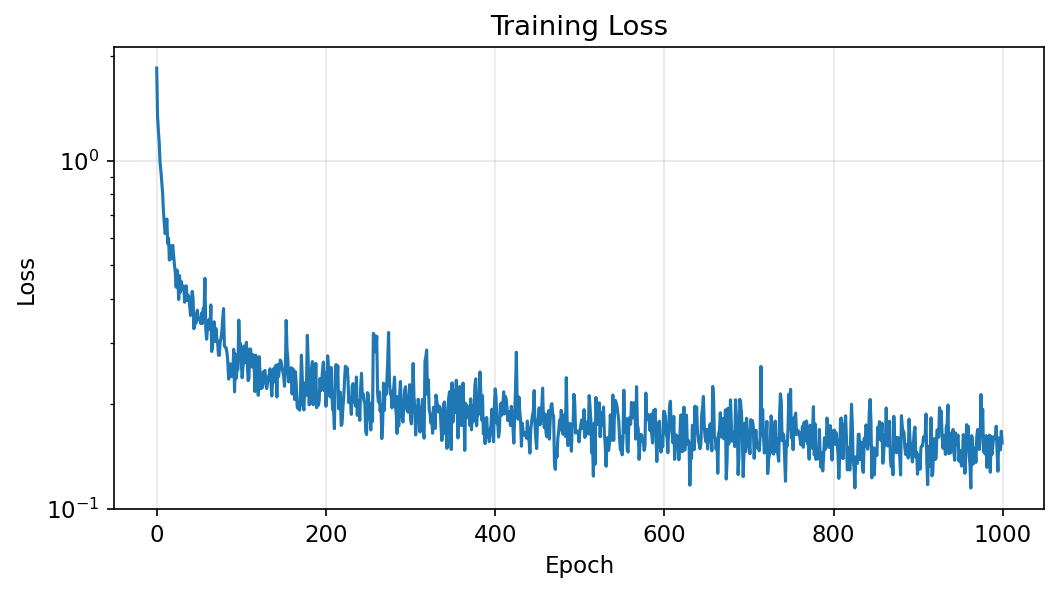

In [4]:
# Train: generate [R, RT] conditioned on [Ca, Cb]
x_data = np.column_stack([R, RT])  # inputs to generate
c_data = np.column_stack([Ca, Cb])  # conditioning outputs

fm_map = ConditionalFlowMatching(x_dim=2, c_dim=2, hidden_dim=128, n_layers=4)
losses = fm_map.fit(x_data, c_data, epochs=1000, batch_size=64)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.semilogy(losses['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Visualize Velocity Fields

Show the learned velocity field at different times, conditioned on a specific output value.

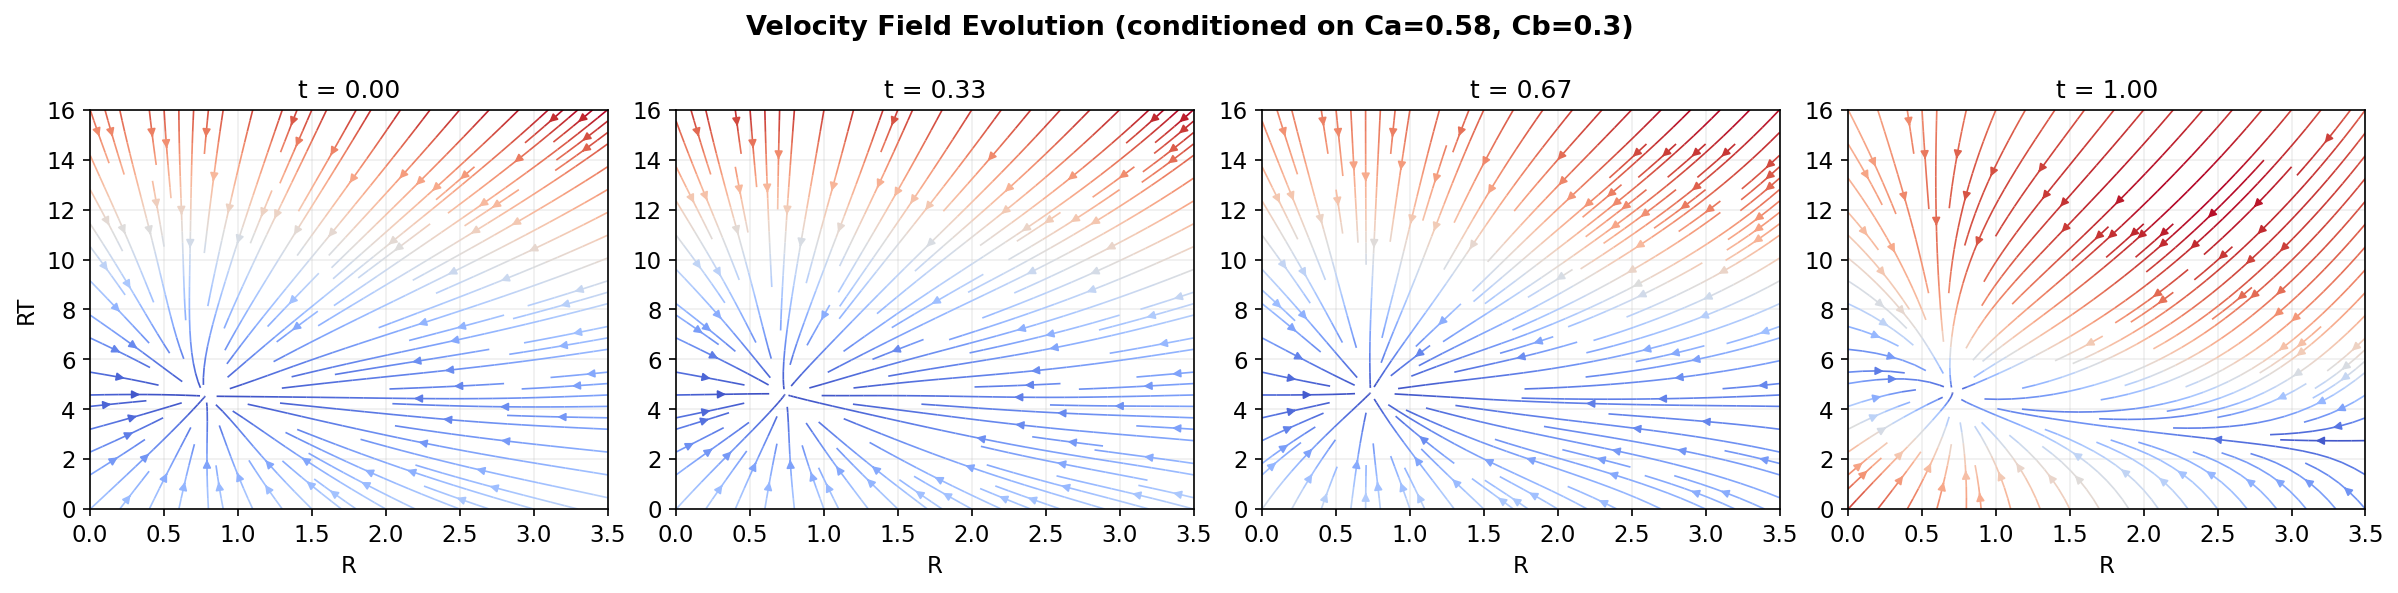

In [5]:
def compute_conditional_velocity_field(model, c_val, xlim, ylim, t_val, n_grid=20):
    """Compute velocity field on a grid for a specific conditioning value."""
    x = np.linspace(xlim[0], xlim[1], n_grid)
    y = np.linspace(ylim[0], ylim[1], n_grid)
    X, Y = np.meshgrid(x, y)
    
    points = np.column_stack([X.ravel(), Y.ravel()])
    
    # Normalize points
    points_norm = (points - model.x_mean.cpu().numpy()) / (model.x_std.cpu().numpy() + 1e-8)
    points_t = torch.tensor(points_norm, dtype=torch.float32, device=device)
    
    # Normalize conditioning
    c = torch.tensor(c_val, dtype=torch.float32, device=device)
    c = (c - model.c_mean) / (model.c_std + 1e-8)
    c = c.unsqueeze(0).expand(len(points), -1)
    
    t = torch.full((len(points), 1), t_val, dtype=torch.float32, device=device)
    
    with torch.no_grad():
        v = model.model(points_t, t, c).cpu().numpy()
    
    # Scale velocity back to original space
    v = v * (model.x_std.cpu().numpy() + 1e-8)
    
    U = v[:, 0].reshape(X.shape)
    V = v[:, 1].reshape(X.shape)
    
    return X, Y, U, V


# Target center for conditioning
center = (0.58, 0.3)

# Visualize velocity field at different times
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

times = [0.0, 0.33, 0.67, 1.0]

for i, t in enumerate(times):
    ax = axes[i]
    X, Y, U, V = compute_conditional_velocity_field(
        fm_map, center, [0, 3.5], [0, 16], t, n_grid=18
    )
    magnitude = np.sqrt(U**2 + V**2)
    
    ax.streamplot(X, Y, U, V, color=magnitude, cmap='coolwarm', 
                  density=1.2, linewidth=0.8, arrowsize=0.8)
    ax.set_xlim(0, 3.5)
    ax.set_ylim(0, 16)
    ax.set_title(f't = {t:.2f}', fontsize=12)
    ax.set_xlabel('R')
    if i == 0:
        ax.set_ylabel('RT')
    ax.grid(True, alpha=0.2)

plt.suptitle(f'Velocity Field Evolution (conditioned on Ca={center[0]}, Cb={center[1]})', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Map Desired Output Region to Input Space

In [6]:
# Define desired output region
center = (0.58, 0.3)
radius = 0.08

# Generate points in desired circle
np.random.seed(42)
n_target = 500
theta = np.random.uniform(0, 2*np.pi, n_target)
r = np.sqrt(np.random.uniform(0, 1, n_target)) * radius
Ca_desired = center[0] + r * np.cos(theta)
Cb_desired = center[1] + r * np.sin(theta)

# Map to input space using flow matching
c_values = np.column_stack([Ca_desired, Cb_desired])
mapped = []
for c in tqdm(c_values, desc='Mapping points'):
    s = fm_map.sample(c_values=[c], n_samples=1, n_steps=50)
    mapped.append(s[0])
mapped = np.array(mapped)

P1 = mapped[:, 0]  # Mapped R
P2 = mapped[:, 1]  # Mapped RT

print(f"Mapped {len(mapped)} points")
print(f"Mapped R range: [{P1.min():.2f}, {P1.max():.2f}]")
print(f"Mapped RT range: [{P2.min():.2f}, {P2.max():.2f}]")

Mapping points:   0%|          | 0/500 [00:00<?, ?it/s]

Mapped 500 points
Mapped R range: [0.52, 1.54]
Mapped RT range: [1.73, 10.89]


## 5. Verify Mapping Accuracy

In [7]:
# Verify that mapped designs achieve target outputs
Ca_actual, Cb_actual = cstr_model(P1, P2)

errors_Ca = np.abs(Ca_actual - Ca_desired)
errors_Cb = np.abs(Cb_actual - Cb_desired)

print("Verification of Inverse Mapping:")
print("="*50)
print(f"Mean error in Ca: {errors_Ca.mean():.4f}")
print(f"Mean error in Cb: {errors_Cb.mean():.4f}")
print(f"Max error in Ca: {errors_Ca.max():.4f}")
print(f"Max error in Cb: {errors_Cb.max():.4f}")

# Show some examples
print("\nSample mappings:")
for i in range(5):
    print(f"  Target: Ca={Ca_desired[i]:.4f}, Cb={Cb_desired[i]:.4f}")
    print(f"  Mapped: R={P1[i]:.3f}, RT={P2[i]:.3f}")
    print(f"  Actual: Ca={Ca_actual[i]:.4f}, Cb={Cb_actual[i]:.4f}")
    print()

Verification of Inverse Mapping:
Mean error in Ca: 0.0052
Mean error in Cb: 0.0025
Max error in Ca: 0.0628
Max error in Cb: 0.0689

Sample mappings:
  Target: Ca=0.5329, Cb=0.3474
  Mapped: R=0.903, RT=3.907
  Actual: Ca=0.5427, Cb=0.3498

  Target: Ca=0.6358, Cb=0.2821
  Mapped: R=0.671, RT=4.063
  Actual: Ca=0.6429, Cb=0.2795

  Target: Ca=0.5750, Cb=0.2558
  Mapped: R=0.607, RT=7.109
  Actual: Ca=0.5798, Cb=0.2556

  Target: Ca=0.5213, Cb=0.2581
  Mapped: R=0.644, RT=8.525
  Actual: Ca=0.5298, Cb=0.2569

  Target: Ca=0.6169, Cb=0.3550
  Mapped: R=1.059, RT=2.340
  Actual: Ca=0.6082, Cb=0.3619



## 6. Visualization (Matching GMM Style)

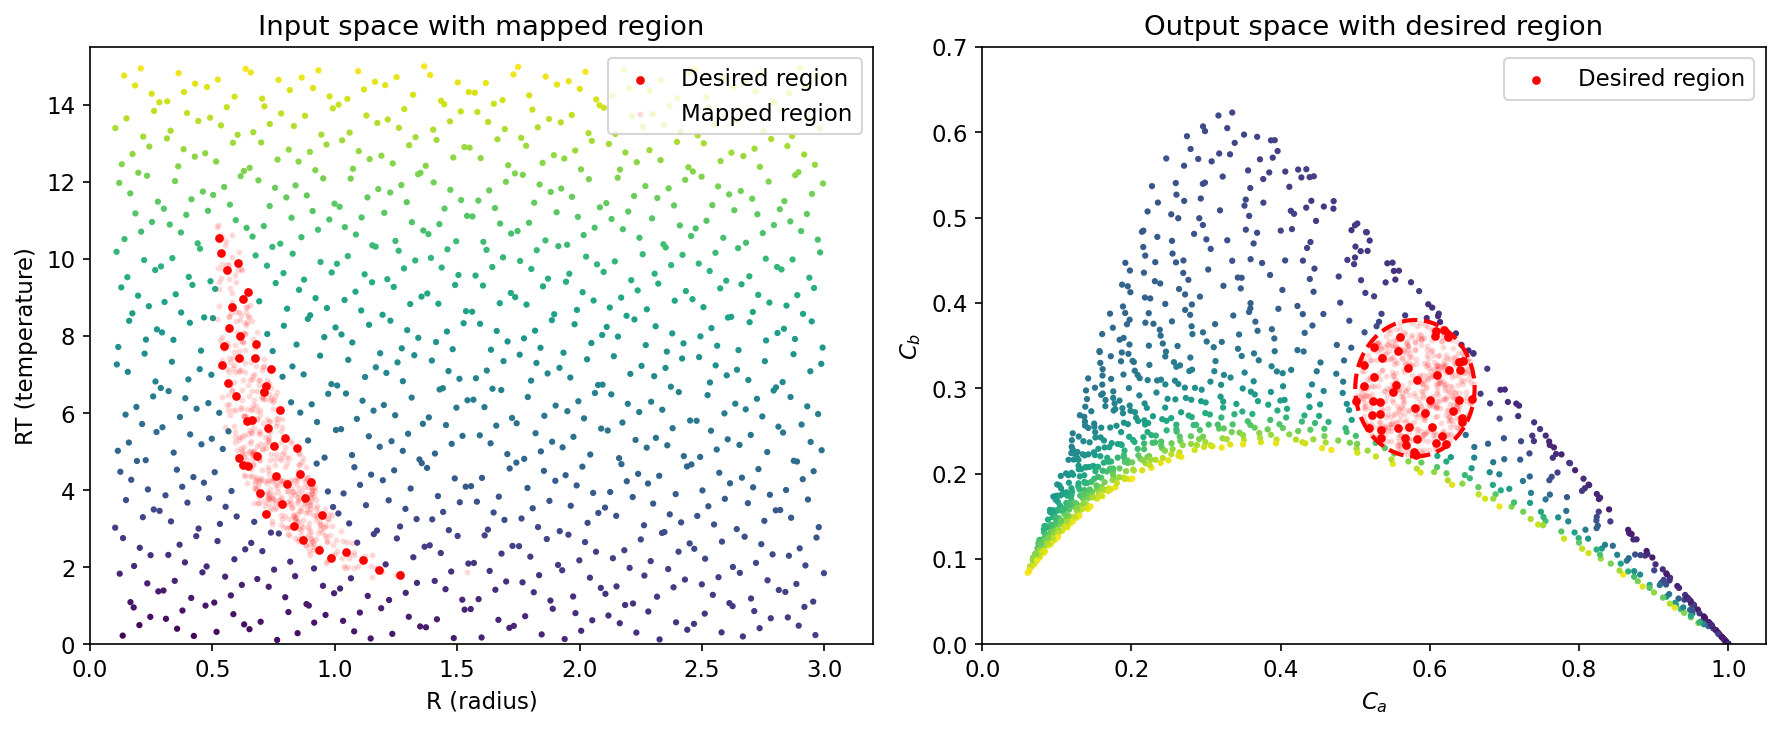

In [8]:
# Find points that naturally fall in desired region
dos = ((Ca - center[0])**2 + (Cb - center[1])**2) <= radius**2

# Color by distance from origin (matching original style)
colors = np.sqrt(R**2 + RT**2)

# Create visualization matching the original GMM style
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Input space (left)
axes[0].scatter(R, RT, s=4, c=colors, cmap='viridis')
axes[0].scatter(R[dos], RT[dos], c='red', s=10, label='Desired region')
axes[0].scatter(P1, P2, s=4, c='red', alpha=0.1, label='Mapped region')
axes[0].set_xlabel('R (radius)')
axes[0].set_ylabel('RT (temperature)')
axes[0].set_title('Input space with mapped region')
axes[0].legend()
axes[0].set_xlim(0, 3.2)
axes[0].set_ylim(0, 15.5)

# Output space (right)
axes[1].scatter(Ca, Cb, s=4, c=colors, cmap='viridis')
axes[1].scatter(Ca[dos], Cb[dos], c='red', s=10, label='Desired region')
circle = plt.Circle(center, radius, fill=False, color='red', linestyle='--', linewidth=2)
axes[1].add_patch(circle)
axes[1].scatter(Ca_desired, Cb_desired, c='red', s=4, alpha=0.1)
axes[1].set_xlabel('$C_a$')
axes[1].set_ylabel('$C_b$')
axes[1].set_title('Output space with desired region')
axes[1].legend()
axes[1].set_xlim(0, 1.05)
axes[1].set_ylim(0, 0.7)

plt.tight_layout()

## 7. Detailed Trajectory Visualization

In [9]:
def integrate_trajectory(model, c_val, n_steps=60):
    """Integrate a single trajectory through the conditional flow."""
    model.model.eval()
    
    # Normalize conditioning
    c = torch.tensor(c_val, dtype=torch.float32, device=device)
    c = (c - model.c_mean) / (model.c_std + 1e-8)
    c = c.unsqueeze(0)
    
    # Start from random noise
    torch.manual_seed(42)  # For reproducibility
    x = torch.randn(1, model.x_dim, device=device)
    
    trajectory = [model._unnormalize_x(x).cpu().numpy()[0].copy()]
    times = [0.0]
    
    dt = 1.0 / n_steps
    with torch.no_grad():
        for step in range(n_steps):
            t = torch.tensor(step / n_steps, device=device)
            v = model.model(x, t, c)
            x = x + v * dt
            
            trajectory.append(model._unnormalize_x(x).cpu().numpy()[0].copy())
            times.append((step + 1) / n_steps)
    
    return np.array(times), np.array(trajectory)


# Integrate trajectories for several target points
np.random.seed(123)
n_traj = 20
traj_idx = np.random.choice(len(Ca_desired), n_traj, replace=False)

trajectories = []
for idx in tqdm(traj_idx, desc='Integrating trajectories'):
    c_val = [Ca_desired[idx], Cb_desired[idx]]
    t, traj = integrate_trajectory(fm_map, c_val, n_steps=60)
    trajectories.append({
        't': t,
        'traj': traj,
        'target_output': c_val,
        'final_input': traj[-1]
    })

print(f"Integrated {len(trajectories)} trajectories")

Integrating trajectories:   0%|          | 0/20 [00:00<?, ?it/s]

Integrated 20 trajectories


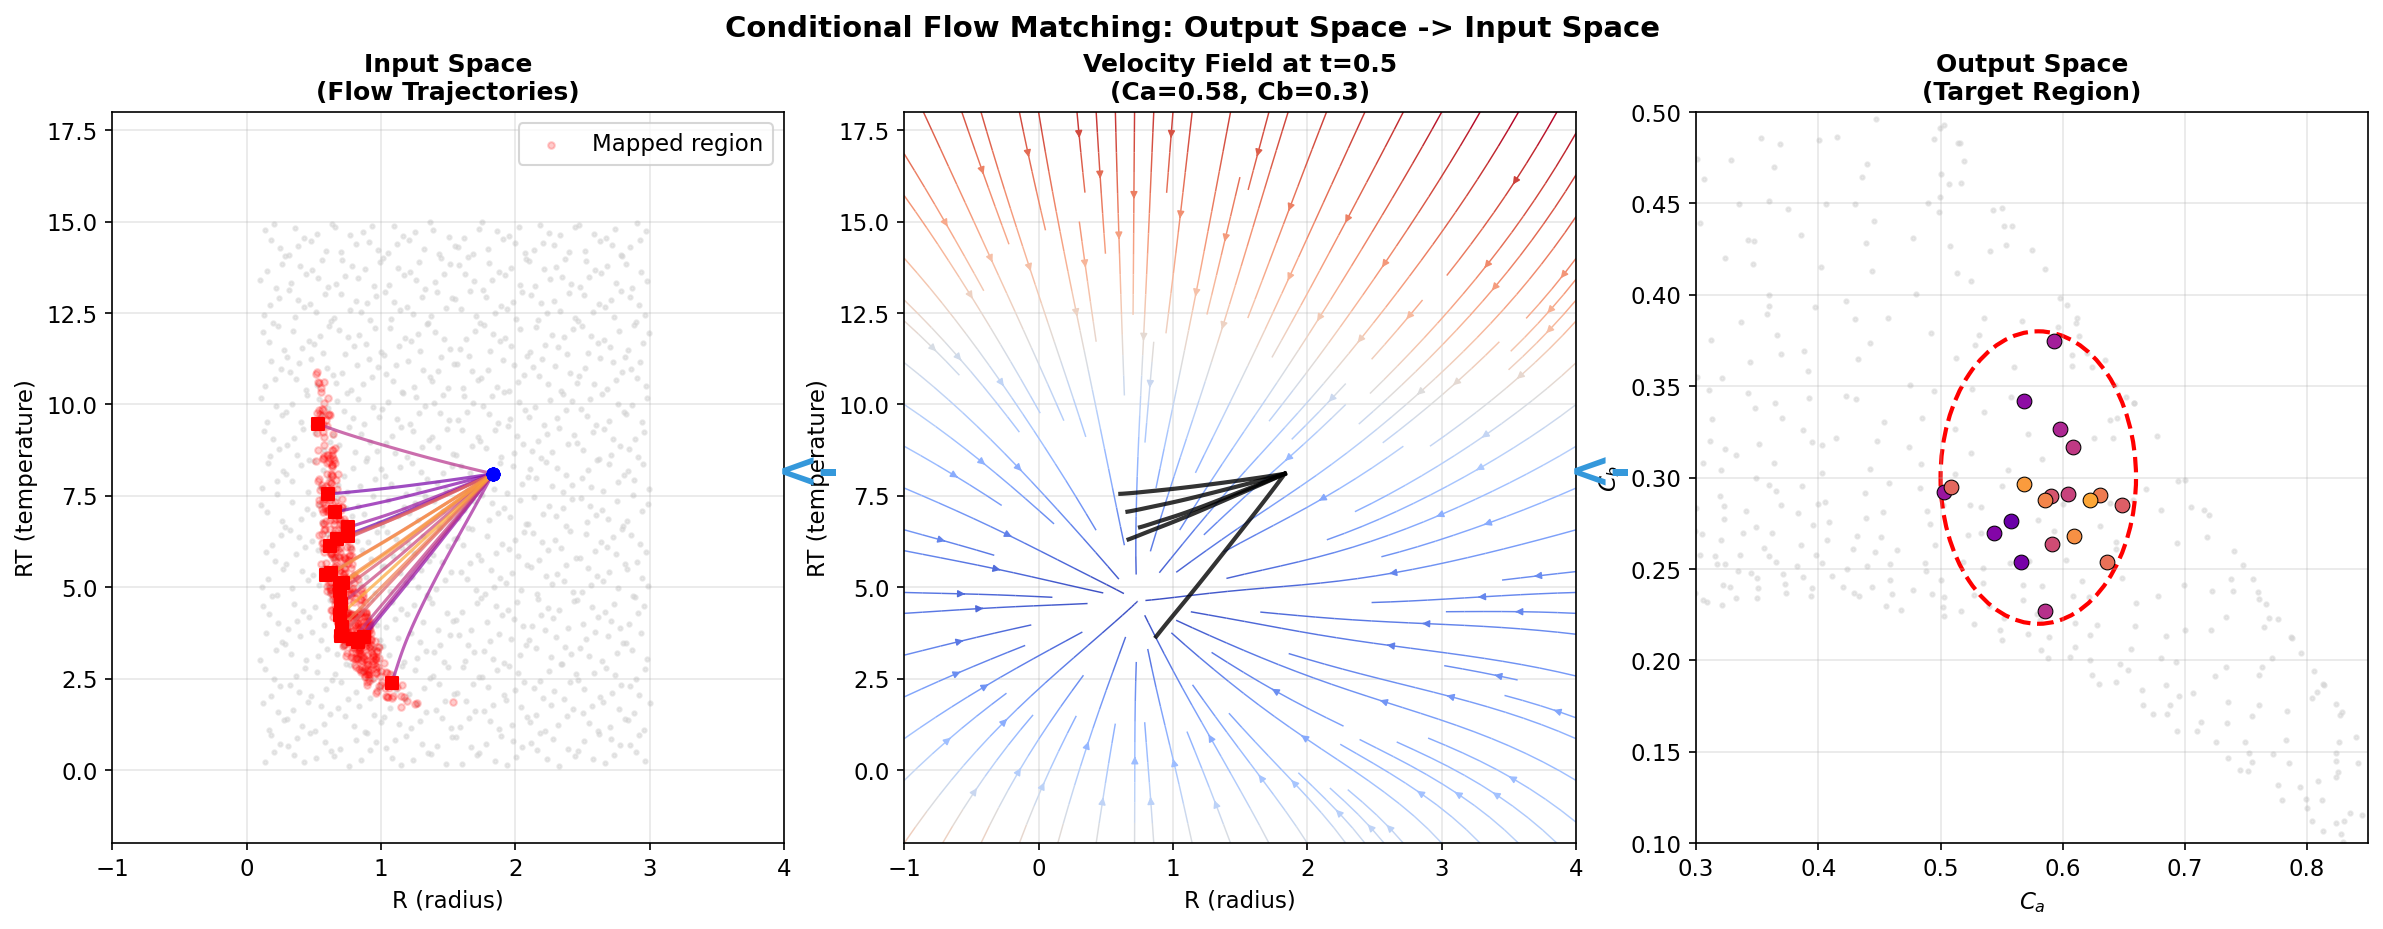

In [10]:
# Create comprehensive visualization with trajectories
fig = plt.figure(figsize=(16, 6.5))

# Left: Input space with trajectories
ax1 = fig.add_axes([0.05, 0.10, 0.28, 0.75])

# Middle: Velocity field
ax2 = fig.add_axes([0.38, 0.10, 0.28, 0.75])

# Right: Output space
ax3 = fig.add_axes([0.71, 0.10, 0.28, 0.75])

# Color map for trajectories
cmap = plt.cm.plasma
traj_colors = cmap(np.linspace(0.2, 0.8, n_traj))

# ===== Input Space (Left) =====
ax1.scatter(R, RT, c='lightgray', s=4, alpha=0.5)
ax1.scatter(P1, P2, c='red', s=10, alpha=0.2, label='Mapped region')

# Plot trajectories
for i, traj_data in enumerate(trajectories):
    traj = traj_data['traj']
    ax1.plot(traj[:, 0], traj[:, 1], c=traj_colors[i], lw=1.5, alpha=0.7)
    ax1.scatter(traj[0, 0], traj[0, 1], c='blue', s=30, marker='o', zorder=5)
    ax1.scatter(traj[-1, 0], traj[-1, 1], c='red', s=30, marker='s', zorder=5)

ax1.set_xlabel('R (radius)', fontsize=11)
ax1.set_ylabel('RT (temperature)', fontsize=11)
ax1.set_title('Input Space\n(Flow Trajectories)', fontsize=12, fontweight='bold')
ax1.set_xlim(-1, 4)
ax1.set_ylim(-2, 18)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ===== Velocity Field (Middle) =====
X, Y, U, V = compute_conditional_velocity_field(
    fm_map, center, [-1, 4], [-2, 18], 0.5, n_grid=18
)
magnitude = np.sqrt(U**2 + V**2)
ax2.streamplot(X, Y, U, V, color=magnitude, cmap='coolwarm', 
               density=1.2, linewidth=0.7, arrowsize=0.7)

# Add sample trajectories
for i, traj_data in enumerate(trajectories[:5]):
    traj = traj_data['traj']
    ax2.plot(traj[:, 0], traj[:, 1], c='black', lw=2, alpha=0.8)

ax2.set_xlabel('R (radius)', fontsize=11)
ax2.set_ylabel('RT (temperature)', fontsize=11)
ax2.set_title(f'Velocity Field at t=0.5\n(Ca={center[0]}, Cb={center[1]})', fontsize=12, fontweight='bold')
ax2.set_xlim(-1, 4)
ax2.set_ylim(-2, 18)
ax2.grid(True, alpha=0.3)

# ===== Output Space (Right) =====
ax3.scatter(Ca, Cb, c='lightgray', s=4, alpha=0.5)

# Target circle
circle = Circle(center, radius, fill=False, color='red', linewidth=2, linestyle='--')
ax3.add_patch(circle)

# Show target points for trajectories
for i, traj_data in enumerate(trajectories):
    target = traj_data['target_output']
    ax3.scatter(target[0], target[1], c=[traj_colors[i]], s=50, 
                marker='o', edgecolors='black', linewidths=0.5, zorder=5)

ax3.set_xlabel('$C_a$', fontsize=11)
ax3.set_ylabel('$C_b$', fontsize=11)
ax3.set_title('Output Space\n(Target Region)', fontsize=12, fontweight='bold')
ax3.set_xlim(0.3, 0.85)
ax3.set_ylim(0.1, 0.5)
ax3.grid(True, alpha=0.3)

# Add arrows between plots
fig.text(0.34, 0.48, '<-', fontsize=24, ha='center', va='center', fontweight='bold', color='#3498DB')
fig.text(0.67, 0.48, '<-', fontsize=24, ha='center', va='center', fontweight='bold', color='#3498DB')

plt.suptitle('Conditional Flow Matching: Output Space -> Input Space', fontsize=14, fontweight='bold', y=0.95)
plt.show()

### Interpreting the Trajectory Visualization

**Color coding:** Each trajectory has a unique color from the plasma colormap. The colored circles in the output space (right panel) show the target (Ca, Cb) values, and the corresponding trajectories in the input space (left panel) use the same colors. This allows you to trace which target output led to which input trajectory.

**Why one starting point goes to many endpoints:** All trajectories begin at the same blue circle in the input space. This is because `integrate_trajectory()` uses a fixed random seed (`torch.manual_seed(42)`), so every trajectory starts from identical noise. However, each trajectory is *conditioned* on a different target output (Ca, Cb). The conditional velocity field learned by the model guides each trajectory toward a different final input (R, RT) - the one that produces the specified target output. This demonstrates the key property of conditional flow matching: the same starting noise can be transformed into different valid designs depending on the conditioning value.

## Summary

This notebook demonstrated **Conditional Flow Matching** for inverse design:

1. **Model**: Learns a conditional velocity field that transports noise to valid design parameters, conditioned on desired outputs

2. **Training**: Uses the optimal transport interpolation path between noise and data

3. **Inverse Design**: Given desired (Ca, Cb), generates feasible (R, RT) by integrating the learned velocity field

4. **Visualization**: Shows both the mapped region and the flow trajectories

**Key advantages over unconditional flows:**
- Directly conditions on target outputs
- More accurate inverse mapping
- Proper handling of normalization

---
## References

1. **Lipman, Y., Chen, R. T., Ben-Hamu, H., Nickel, M., & Le, M.** (2023). Flow matching for generative modeling. *ICLR 2023*. https://arxiv.org/abs/2210.02747

2. **Tong, A., Malkin, N., Huguet, G., Zhang, Y., Rector-Brooks, J., Fatras, K., Wolf, G., & Bengio, Y.** (2024). Improving and generalizing flow-based generative models with minibatch optimal transport. *TMLR*. https://arxiv.org/abs/2302.00482

3. **Chen, R. T., Rubanova, Y., Bettencourt, J., & Duvenaud, D.** (2018). Neural ordinary differential equations. *NeurIPS 2018*. https://arxiv.org/abs/1806.07366

In [11]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 08:25:27
End time:        2025-12-18 08:25:48
Elapsed time:    20.72 seconds (0.35 minutes)
----------------------------------------------------------------------
Initial memory:  300.14 MB
Final memory:    489.33 MB
Memory change:   +189.19 MB
